# Funcion para obtener las frecuencias bajas que representan la piel humana
Se hace uso de filtros pasa bajas

In [ ]:
# librerias
import cv as cv
import numpy as np
import matplotlib.pyplot as plt

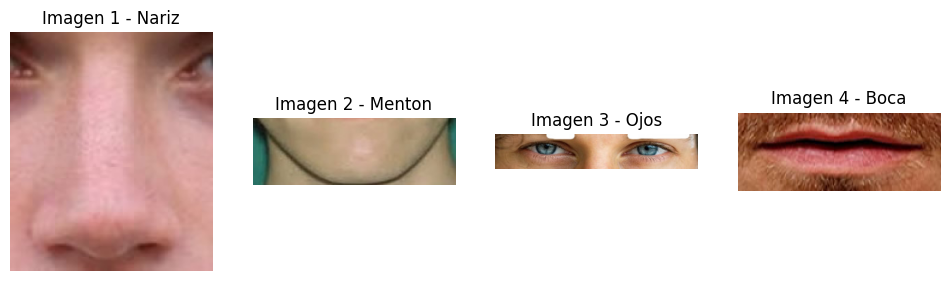

In [20]:
# load images
img1 = cv.imread("images/nariz/hn001.jpg", cv.IMREAD_UNCHANGED)
img2 = cv.imread("images/menton/hm004.jpg", cv.IMREAD_UNCHANGED)
img3 = cv.imread("images/ojos/ho002.jpg", cv.IMREAD_UNCHANGED)
img4 = cv.imread("images/boca/hb001.jpg", cv.IMREAD_UNCHANGED)

# plot images
plt.figure(figsize=(12, 6))
plt.subplot(1, 4, 1)
plt.imshow(cv.cvtColor(img1, cv.COLOR_BGR2RGB))
plt.title("Imagen 1 - Nariz")
plt.axis("off")
plt.subplot(1, 4, 2)
plt.imshow(cv.cvtColor(img2, cv.COLOR_BGR2RGB))
plt.title("Imagen 2 - Menton")
plt.axis("off")
plt.subplot(1, 4, 3)
plt.imshow(cv.cvtColor(img3, cv.COLOR_BGR2RGB))
plt.title("Imagen 3 - Ojos")
plt.axis("off")
plt.subplot(1, 4, 4)
plt.imshow(cv.cvtColor(img4, cv.COLOR_BGR2RGB))
plt.title("Imagen 4 - Boca")
plt.axis("off")
plt.show()

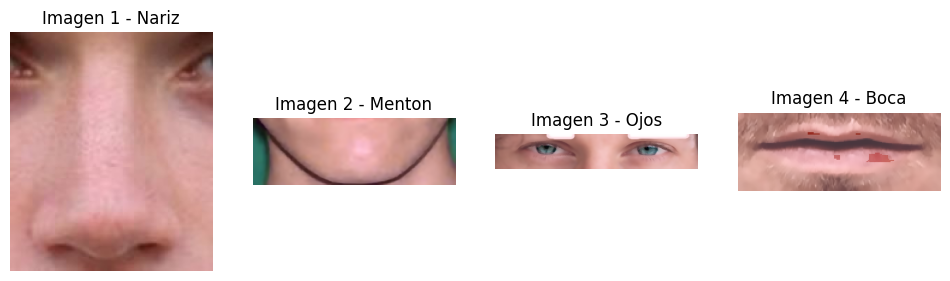

In [27]:
def skin_mask(img):
    img_ycrcb = cv.cvtColor(img, cv.COLOR_BGR2YCrCb)
    mask = cv.inRange(img_ycrcb,
                       np.array([0, 133, 77]),
                       np.array([255, 173, 127]))
    return cv.GaussianBlur(mask, (7, 7), 0)


def reinhard_color_transfer(src, target, mask_src, mask_tgt):
    # Convertir a LAB
    src_lab = cv.cvtColor(src, cv.COLOR_BGR2LAB).astype(np.float32)
    tgt_lab = cv.cvtColor(target, cv.COLOR_BGR2LAB).astype(np.float32)

    # Extraer píxeles de piel en ambas imágenes
    src_pixels = src_lab[mask_src > 0]
    tgt_pixels = tgt_lab[mask_tgt > 0]

    # Si alguna máscara está vacía, regresar la imagen original
    if len(src_pixels) == 0 or len(tgt_pixels) == 0:
        return src

    # Estadísticas
    src_mean, src_std = src_pixels.mean(axis=0), src_pixels.std(axis=0)
    tgt_mean, tgt_std = tgt_pixels.mean(axis=0), tgt_pixels.std(axis=0)

    src_std[src_std == 0] = 1

    # Aplicar a todos los píxeles de piel del src
    result = src_lab.copy()
    result[mask_src > 0] = ((src_pixels - src_mean) * (tgt_std / src_std)) + tgt_mean

    result = np.clip(result, 0, 255)
    result_bgr = cv.cvtColor(result.astype(np.uint8), cv.COLOR_LAB2BGR)
    return result_bgr


def match_skin_tone(images, ref_index=0):
    reference = images[ref_index]
    mask_ref = skin_mask(reference)

    adjusted_images = []

    for i, img in enumerate(images):
        if i == ref_index:
            adjusted_images.append(img)
            continue

        mask_src = skin_mask(img)

        result = reinhard_color_transfer(img, reference, mask_src, mask_ref)
        result = cv.bilateralFilter(result, 7, 50, 50)

        adjusted_images.append(result)

    return adjusted_images



images = [img1, img2, img3, img4]

img_filtered = match_skin_tone(images, ref_index=0)

# plot images
plt.figure(figsize=(12, 6))
plt.subplot(1, 4, 1)
plt.imshow(cv.cvtColor(img_filtered[0], cv.COLOR_BGR2RGB))
plt.title("Imagen 1 - Nariz")
plt.axis("off")
plt.subplot(1, 4, 2)
plt.imshow(cv.cvtColor(img_filtered[1], cv.COLOR_BGR2RGB))
plt.title("Imagen 2 - Menton")
plt.axis("off")
plt.subplot(1, 4, 3)
plt.imshow(cv.cvtColor(img_filtered[2], cv.COLOR_BGR2RGB))
plt.title("Imagen 3 - Ojos")
plt.axis("off")
plt.subplot(1, 4, 4)
plt.imshow(cv.cvtColor(img_filtered[3], cv.COLOR_BGR2RGB))
plt.title("Imagen 4 - Boca")
plt.axis("off")
plt.show()
